In [1]:
# Segmentation demos
# see https://huggingface.co/docs/transformers/v4.48.0/en/tasks/semantic_segmentation
# pip requirements:
# !pip install -q datasets transformers evaluate accelerate scipy

In [2]:
import torch
from torch import nn
import numpy as np
from transformers import pipeline
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


import requests
from transformers import SegformerFeatureExtractor, SegformerForSemanticSegmentation
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

# url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/segmentation_input.jpg"
# image = Image.open(requests.get(url, stream=True).raw)
# image

(640, 480)


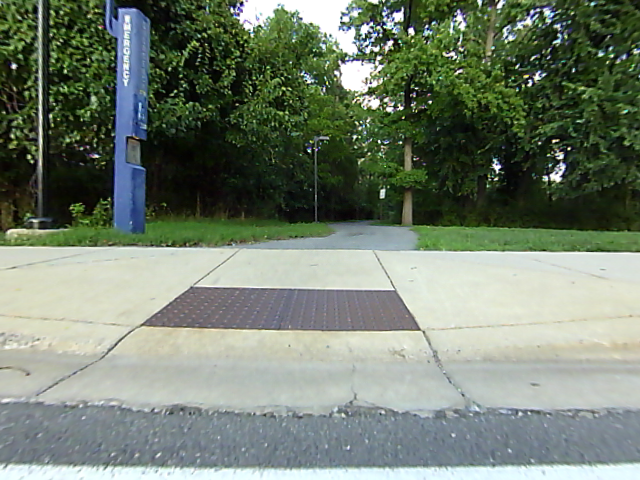

In [18]:
image = Image.open("UMD_585.png")
print(image.size)
image

In [3]:
# Segformer
semantic_segmentation = pipeline("image-segmentation", "nvidia/segformer-b1-finetuned-cityscapes-1024-1024")
results = semantic_segmentation(image)
print(len(results))
results

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0


8


[{'score': None,
  'label': 'road',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': None,
  'label': 'sidewalk',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': None,
  'label': 'building',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': None,
  'label': 'pole',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': None,
  'label': 'vegetation',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': None,
  'label': 'terrain',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': None,
  'label': 'sky',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': None,
  'label': 'car',
  'mask': <PIL.Image.Image image mode=L size=640x480>}]

terrain


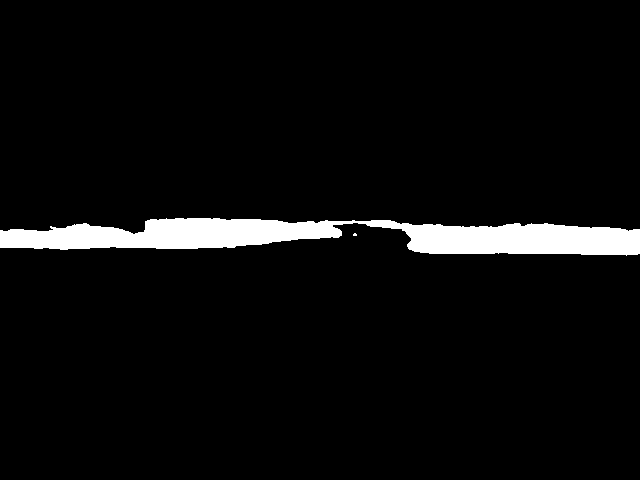

In [6]:
idx = 5
print(results[idx]['label'])
results[idx]['mask']

In [5]:
feature_extractor = SegformerFeatureExtractor.from_pretrained("nvidia/segformer-b1-finetuned-cityscapes-1024-1024")
model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b1-finetuned-cityscapes-1024-1024")

inputs = feature_extractor(images=image, return_tensors="pt")
outputs = model(**inputs)
logits = outputs.logits  # [batch, n_classes, h, w]??
print(logits.shape)
print(model.config.id2label)


/home/jim/Documents/Projects/SERNet-Former/.venv/lib/python3.12/site-packages/transformers/models/segformer/feature_extraction_segformer.py:28: FutureWarning: The class SegformerFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use SegformerImageProcessor instead.
  warnings.warn(
/home/jim/Documents/Projects/SERNet-Former/.venv/lib/python3.12/site-packages/transformers/utils/deprecation.py:165: UserWarning: The following named arguments are not valid for `SegformerFeatureExtractor.__init__` and were ignored: 'feature_extractor_type'
  return func(*args, **kwargs)


torch.Size([1, 19, 256, 256])
{0: 'road', 1: 'sidewalk', 2: 'building', 3: 'wall', 4: 'fence', 5: 'pole', 6: 'traffic light', 7: 'traffic sign', 8: 'vegetation', 9: 'terrain', 10: 'sky', 11: 'person', 12: 'rider', 13: 'car', 14: 'truck', 15: 'bus', 16: 'train', 17: 'motorcycle', 18: 'bicycle'}


In [26]:
# Panoptic segmentation combines semantic segmentation and instance segmentation,
# where every pixel is classified into a class and an instance of that class,
# and there are multiple masks for each instance of a class.
panoptic_segmentation = pipeline("image-segmentation", "facebook/mask2former-swin-large-cityscapes-panoptic")
results = panoptic_segmentation(image)
print(len(results))
results

Device set to use cuda:0
`label_ids_to_fuse` unset. No instance will be fused.


8


[{'score': 0.999982,
  'label': 'vegetation',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': 0.99979,
  'label': 'pole',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': 0.999789,
  'label': 'terrain',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': 0.999966,
  'label': 'building',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': 0.982447,
  'label': 'person',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': 0.998211,
  'label': 'wall',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': 0.998425,
  'label': 'road',
  'mask': <PIL.Image.Image image mode=L size=640x480>},
 {'score': 0.999932,
  'label': 'sky',
  'mask': <PIL.Image.Image image mode=L size=640x480>}]

wall


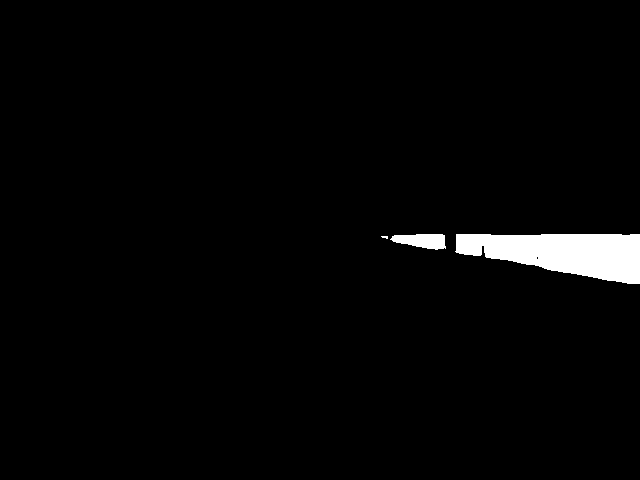

In [27]:
idx = 5
print(results[idx]['label'])
results[idx]['mask']

In [5]:
# load Mask2Former fine-tuned on Cityscapes instance segmentation
processor = AutoImageProcessor.from_pretrained("facebook/mask2former-swin-small-cityscapes-semantic")
model = Mask2FormerForUniversalSegmentation.from_pretrained("facebook/mask2former-swin-small-cityscapes-semantic")

inputs = processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

# model predicts class_queries_logits of shape `(batch_size, num_queries)`
# and masks_queries_logits of shape `(batch_size, num_queries, height, width)`
class_queries_logits = outputs.class_queries_logits
masks_queries_logits = outputs.masks_queries_logits

# you can pass them to processor for postprocessing
results = processor.post_process_instance_segmentation(outputs, target_sizes=[image.size[::-1]])[0]
# we refer to the demo notebooks for visualization (see "Resources" section in the Mask2Former docs)
predicted_instance_map = results["segmentation"]


In [11]:
print(image.size)
print(image.size[::-1])

(640, 480)
(480, 640)


In [10]:
print(results['segmentation'].shape)
print(results['segments_info'])
print(model.config.id2label)

torch.Size([480, 640])
[{'id': 0, 'label_id': 7, 'was_fused': False, 'score': 0.894063}, {'id': 1, 'label_id': 3, 'was_fused': False, 'score': 0.890144}, {'id': 2, 'label_id': 0, 'was_fused': False, 'score': 0.841098}, {'id': 3, 'label_id': 6, 'was_fused': False, 'score': 0.557713}, {'id': 4, 'label_id': 4, 'was_fused': False, 'score': 0.730253}, {'id': 5, 'label_id': 10, 'was_fused': False, 'score': 0.967718}, {'id': 6, 'label_id': 2, 'was_fused': False, 'score': 0.882066}, {'id': 7, 'label_id': 8, 'was_fused': False, 'score': 0.971922}, {'id': 8, 'label_id': 13, 'was_fused': False, 'score': 0.891601}, {'id': 9, 'label_id': 5, 'was_fused': False, 'score': 0.89811}, {'id': 10, 'label_id': 11, 'was_fused': False, 'score': 0.905573}, {'id': 11, 'label_id': 4, 'was_fused': False, 'score': 0.713341}, {'id': 12, 'label_id': 9, 'was_fused': False, 'score': 0.972848}]
{0: 'road', 1: 'sidewalk', 2: 'building', 3: 'wall', 4: 'fence', 5: 'pole', 6: 'traffic light', 7: 'traffic sign', 8: 'vegetat

{0: 10, 1: 5, 2: 8, 3: 9}
Visualizing mask for: vegetation


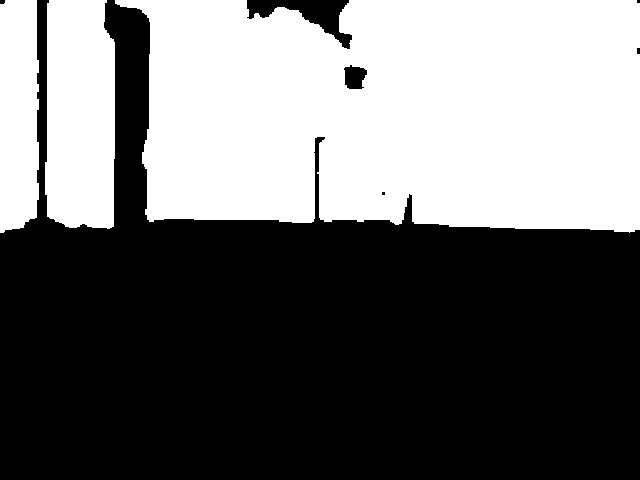

In [20]:
# for further visualizations!!
# https://github.com/NielsRogge/Transformers-Tutorials/blob/master/Mask2Former/Inference_with_Mask2Former.ipynb

def get_mask(model, mask_results, segment_id):
    segment_to_label = {segment['id']: segment['label_id'] for segment in mask_results["segments_info"]}
    print(segment_to_label)
    print("Visualizing mask for:", model.config.id2label[segment_to_label[segment_id]])

    mask = (mask_results['segmentation'].numpy() == segment_id)
    visual_mask = (mask * 255).astype(np.uint8)
    visual_mask = Image.fromarray(visual_mask)

    return visual_mask

get_mask(model, results, 2)


In [21]:
# https://github.com/NielsRogge/Transformers-Tutorials/blob/master/Mask2Former/Inference_with_Mask2Former.ipynb
# Semantic segmentation from the same dataset:
processor = AutoImageProcessor.from_pretrained("facebook/mask2former-swin-small-cityscapes-semantic")
model = Mask2FormerForUniversalSegmentation.from_pretrained("facebook/mask2former-swin-small-cityscapes-semantic")
inputs = processor(images=image, return_tensors="pt")
for k,v in inputs.items():
    print(k,v.shape)
with torch.no_grad():
    outputs = model(**inputs)

# model predicts class_queries_logits of shape `(batch_size, num_queries)`
# and masks_queries_logits of shape `(batch_size, num_queries, height, width)`
class_queries_logits = outputs.class_queries_logits
masks_queries_logits = outputs.masks_queries_logits

# you can pass them to processor for postprocessing
results = processor.post_process_semantic_segmentation(outputs, target_sizes=[image.size[::-1]])[0]
print(results.shape)
# print(model.config.id2label)

/home/jim/Documents/Projects/SERNet-Former/.venv/lib/python3.12/site-packages/transformers/utils/deprecation.py:165: UserWarning: The following named arguments are not valid for `Mask2FormerImageProcessor.__init__` and were ignored: '_max_size'
  return func(*args, **kwargs)


pixel_values torch.Size([1, 3, 384, 384])
pixel_mask torch.Size([1, 384, 384])
torch.Size([480, 640])


In [22]:
# generate random color palette, which maps each class to a RGB value
color_palette = [list(np.random.choice(range(256), size=3)) for _ in range(len(model.config.id2label))]

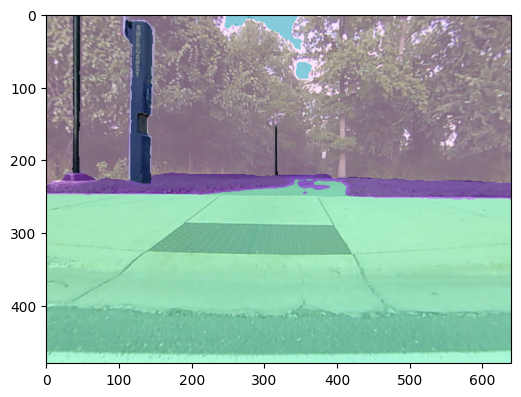

In [23]:
seg = results
color_seg = np.zeros((seg.shape[0], seg.shape[1], 3), dtype=np.uint8) # height, width, 3
palette = np.array(color_palette)
for label, color in enumerate(palette):
    color_seg[seg == label, :] = color
# Convert to BGR
color_seg = color_seg[..., ::-1]

# Show image + mask
img = np.array(image) * 0.5 + color_seg * 0.5
img = img.astype(np.uint8)

plt.figure(figsize=(6, 8))
plt.imshow(img)
plt.show()

{0: 'road', 1: 'sidewalk', 2: 'building', 3: 'wall', 4: 'fence', 5: 'pole', 6: 'traffic light', 7: 'traffic sign', 8: 'vegetation', 9: 'terrain', 10: 'sky', 11: 'person', 12: 'rider', 13: 'car', 14: 'truck', 15: 'bus', 16: 'train', 17: 'motorcycle', 18: 'bicycle'}


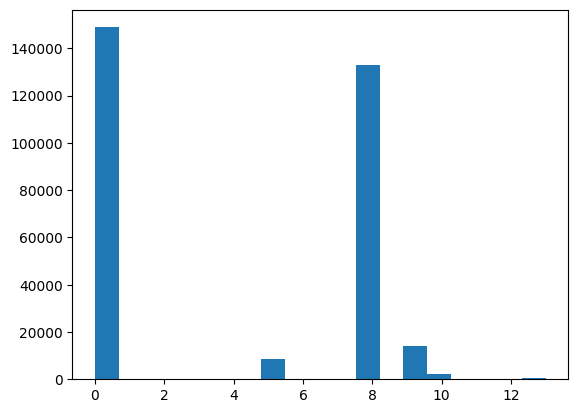

In [24]:
seg_array = np.array(seg.flatten().detach().cpu().numpy())
plt.hist(seg_array, bins=len(model.config.id2label))
print(model.config.id2label)

vegetation


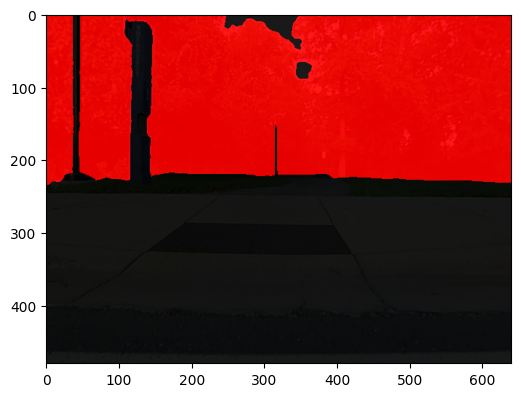

In [25]:
seg = results
color_seg = np.zeros((seg.shape[0], seg.shape[1], 3), dtype=np.uint8) # height, width, 3
palette = np.array(color_palette)
label = 8
print(model.config.id2label[label])
palette = np.array(color_palette)[label]
color_seg[seg == label, :] = (0, 0, 255) # BGR
# Convert to BGR
color_seg = color_seg[..., ::-1]

# Show image + mask
img = np.array(image) * 0.1 + color_seg * 0.9
img = img.astype(np.uint8)

plt.figure(figsize=(6, 8))
plt.imshow(img)
plt.show()

In [27]:
np.array(image).shape

(480, 640, 3)

In [28]:
color_seg.shape

(480, 640, 3)

In [30]:
image.size

(640, 480)

In [31]:
seg.shape

torch.Size([480, 640])